# Final Project Model Deployment
## Credit Score Classification :Dataset C
NIM: 2802413064  
Dataset: C 
### Konteks Bisnis
Sebagai data scientist di institusi keuangan, tugas kita adalah menilai performa kredit nasabah secara otomatis. Setiap nasabah diklasifikasikan ke dalam tiga kelas: Good, Standard, atau Poor. Model ini akan dipakai untuk membantu pengambilan keputusan kredit (approval, limit, suku bunga).

### Outline Pengerjaan
1. Setup dan Load Data
2. Exploratory Data Analysis (EDA)
3. Data Cleaning 
4. Preprocessing dan Feature Engineering
5. Train/Test Split 
6. Modelling
7. Evaluation dan Model Selection
8. Save Artifacts

## 1. Setup & Load Data

In [3]:
import os
import re
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                              f1_score, roc_auc_score, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
RANDOM_STATE = 42

ARTIFACT_DIR = '../artifacts'
os.makedirs(ARTIFACT_DIR, exist_ok=True)

In [5]:
# Load dataset C
df = pd.read_csv('data_C.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (25000, 29)


,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0x20419,CUS_0x36e1,August,Gellero,35,132-77-4921,Journalist,20364.57,1626.047500,...,Standard,2500.04,27.576478,9 Years and 8 Months,Yes,26.168109,92.51897591535379,High_spent_Small_value_payments,303.917665,Standard
1,1,0x4579,CUS_0x2a61,August,NaN,46,753-68-0048,Teacher,9786.86,951.571667,...,Standard,2149.9,23.451285,NaN,Yes,11.564437,54.46174813453877,Low_spent_Medium_value_payments,309.130981,Poor
2,2,0x1b923,CUS_0x788b,June,Ben Klaymane,19,276-42-6585,_______,146880.84,12372.070000,...,Good,387.53,31.100297,24 Years and 3 Months,No,98.031931,478.3574716999517,High_spent_Small_value_payments,920.817597,Standard
3,3,0x8ac9,CUS_0x5534,April,Aubinr,39,246-34-3138,Developer,23200.82,NaN,...,Standard,987.07,26.786925,17 Years and 7 Months,Yes,0.000000,65.84983488267585,Low_spent_Large_value_payments,391.890332,Standard
4,4,0x24a41,CUS_0x104f,April,Markm,20,264-84-8069,Architect,11336.835,992.736250,...,Standard,177.98,24.001752,14 Years and 7 Months,Yes,35.562731,NaN,Low_spent_Small_value_payments,228.245999,Standard


## 2. Exploratory Data Analysis (EDA)

### 2.1 Struktur Dataset

In [6]:
print('Info dataset:')
df.info()

Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                25000 non-null  int64  
 1   ID                        25000 non-null  object 
 2   Customer_ID               25000 non-null  object 
 3   Month                     25000 non-null  object 
 4   Name                      22570 non-null  object 
 5   Age                       25000 non-null  object 
 6   SSN                       25000 non-null  object 
 7   Occupation                25000 non-null  object 
 8   Annual_Income             25000 non-null  object 
 9   Monthly_Inhand_Salary     21164 non-null  float64
 10  Num_Bank_Accounts         25000 non-null  int64  
 11  Num_Credit_Card           25000 non-null  int64  
 12  Interest_Rate             25000 non-null  int64  
 13  Num_of_Loan               25000 non-null  objec

Distribusi target Credit_Score:
Credit_Score
Standard    13282
Poor         7268
Good         4450
Name: count, dtype: int64

Proporsi:
Credit_Score
Standard    0.531
Poor        0.291
Good        0.178
Name: proportion, dtype: float64


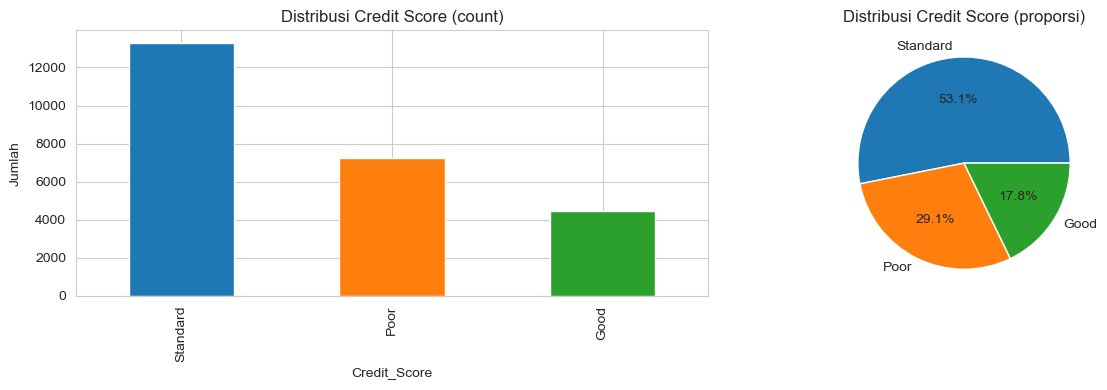

In [7]:
# Distribusi target
print('Distribusi target Credit_Score:')
print(df['Credit_Score'].value_counts())
print('\nProporsi:')
print(df['Credit_Score'].value_counts(normalize=True).round(3))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
df['Credit_Score'].value_counts().plot(kind='bar', ax=ax[0], color=['#1f77b4','#ff7f0e','#2ca02c'])
ax[0].set_title('Distribusi Credit Score (count)')
ax[0].set_ylabel('Jumlah')
df['Credit_Score'].value_counts(normalize=True).plot(kind='pie', ax=ax[1], autopct='%1.1f%%')
ax[1].set_title('Distribusi Credit Score (proporsi)')
ax[1].set_ylabel('')
plt.tight_layout()
plt.show()

Observasi penting: target imbalanced  Standard 53%, Poor 29%, Good 18%. Karena kelas Good adalah minoritas, kita perlu evaluasi yang sensitif terhadap imbalance (macro F1, classification report) dan strategi seperti class_weight='balanced' atau bobot kelas di XGBoost.

In [ ]:
# Cek data panel (berapa banyak record per customer)
panel = df.groupby('Customer_ID').size().value_counts().sort_index()
print('Distribusi jumlah record per Customer_ID:')
print(panel)
print(f'\nTotal unique customers: {df["Customer_ID"].nunique()}')
print('=> Dataset ini bersifat panel (multi-bulan per customer).')
print('=> Train/test split harus per Customer_ID (GroupShuffleSplit) untuk hindari data leakage.')

Distribusi jumlah record per Customer_ID:
1    3375
2    3919
3    2473
4    1132
5     298
6      49
7       8
Name: count, dtype: int64

Total unique customers: 11254
=> Dataset ini bersifat panel (multi-bulan per customer).
=> Train/test split harus per Customer_ID (GroupShuffleSplit) untuk hindari data leakage.


In [10]:
# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'pct': missing_pct})
print('Missing values (NaN bawaan):')
print(missing_df)

Missing values (NaN bawaan):
                         missing_count    pct
Monthly_Inhand_Salary             3836  15.34
Type_of_Loan                      2852  11.41
Name                              2430   9.72
Credit_History_Age                2240   8.96
Num_of_Delayed_Payment            1792   7.17
Amount_invested_monthly           1134   4.54
Num_Credit_Inquiries               472   1.89
Monthly_Balance                    301   1.20


### 2.2 Deteksi Missing Tersembunyi & Nilai Garbage

Selain NaN, dataset ini punya banyak *placeholder* untuk missing/garbage:
- Occupation = '_______'
- Credit_Mix = '_'
- Payment_Behaviour = '!@9#%8'
- Payment_of_Min_Amount = 'NM'
- Kolom numerik (Age, Annual_Income, Num_of_Loan, dll) di-store sebagai string karena ada trailing _ di beberapa baris.

In [11]:
print("Occupation = '_______':", (df['Occupation'] == '_______').sum())
print("Credit_Mix = '_':", (df['Credit_Mix'] == '_').sum())
print("Payment_Behaviour = '!@9#%8':", (df['Payment_Behaviour'] == '!@9#%8').sum())
print("Payment_of_Min_Amount = 'NM':", (df['Payment_of_Min_Amount'] == 'NM').sum())

# Berapa entri numerik yang punya trailing _
for c in ['Age','Annual_Income','Num_of_Loan','Num_of_Delayed_Payment',
          'Changed_Credit_Limit','Outstanding_Debt','Amount_invested_monthly','Monthly_Balance']:
    if df[c].dtype == object:
        bad = df[c].astype(str).str.contains('_', na=False).sum()
        print(f'{c}: rows dengan "_" = {bad}')

Occupation = '_______': 1765
Credit_Mix = '_': 4926
Payment_Behaviour = '!@9#%8': 1951
Payment_of_Min_Amount = 'NM': 2947
Age: rows dengan "_" = 1245
Annual_Income: rows dengan "_" = 1778
Num_of_Loan: rows dengan "_" = 1204
Num_of_Delayed_Payment: rows dengan "_" = 703
Changed_Credit_Limit: rows dengan "_" = 518
Outstanding_Debt: rows dengan "_" = 270
Amount_invested_monthly: rows dengan "_" = 1049


## 3. Data Cleaning

Strategi:
1. Drop kolom identifier: Unnamed: 0, ID,Name, SSN
2. Bersihkan kolom numerik dari karakter aneh, ubah ke numeric
3. Konversi Credit_History_Age ("X Years and Y Months") → total bulan
4. Replace placeholder ke NaN
5. Cap outlier ekstrim (Age negatif, Age > 100, Annual_Income > P99.5, dll)
6. Imputasi via forward/backward fill per Customer_ID (karena data panel) lalu median/mode global untuk sisanya

In [12]:
def clean_dataframe(df_in: pd.DataFrame) -> pd.DataFrame:
    """Berisi semua step cleaning yang reproducible — fungsi yang sama akan di-reuse di pipeline.py"""
    df = df_in.copy()

    # 1. Drop identifier yang tidak prediktif
    drop_cols = ['Unnamed: 0', 'ID', 'Name', 'SSN']
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    # 2. Bersihkan kolom numerik dari karakter '_'
    numeric_dirty = ['Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment',
                     'Changed_Credit_Limit', 'Outstanding_Debt',
                     'Amount_invested_monthly', 'Monthly_Balance']
    for c in numeric_dirty:
        if c in df.columns:
            df[c] = (df[c].astype(str).str.replace('_', '', regex=False)
                                       .replace({'': np.nan, 'nan': np.nan, 'NaN': np.nan}))
            df[c] = pd.to_numeric(df[c], errors='coerce')

    # 3. Credit_History_Age -> total bulan
    def parse_history_age(x):
        if pd.isna(x):
            return np.nan
        m = re.match(r'(\d+)\s+Years?\s+and\s+(\d+)\s+Months?', str(x))
        if m:
            return int(m.group(1)) * 12 + int(m.group(2))
        return np.nan
    if 'Credit_History_Age' in df.columns:
        df['Credit_History_Age'] = df['Credit_History_Age'].apply(parse_history_age)

    # 4. Replace placeholder missing
    df['Occupation'] = df['Occupation'].replace('_______', np.nan)
    df['Credit_Mix'] = df['Credit_Mix'].replace('_', np.nan)
    df['Payment_Behaviour'] = df['Payment_Behaviour'].replace('!@9#%8', np.nan)
    df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].replace('NM', np.nan)

    # 5. Outlier capping berbasis domain knowledge
    df.loc[(df['Age'] < 14) | (df['Age'] > 100), 'Age'] = np.nan
    df.loc[df['Num_Bank_Accounts'] < 0, 'Num_Bank_Accounts'] = np.nan
    df.loc[df['Num_Bank_Accounts'] > 15, 'Num_Bank_Accounts'] = 15
    df.loc[df['Num_Credit_Card'] > 15, 'Num_Credit_Card'] = 15
    df.loc[df['Interest_Rate'] > 40, 'Interest_Rate'] = 40
    df.loc[(df['Num_of_Loan'] < 0) | (df['Num_of_Loan'] > 15), 'Num_of_Loan'] = np.nan
    df.loc[df['Num_of_Delayed_Payment'] < 0, 'Num_of_Delayed_Payment'] = np.nan
    df.loc[df['Num_of_Delayed_Payment'] > 30, 'Num_of_Delayed_Payment'] = 30
    df.loc[df['Num_Credit_Inquiries'] > 30, 'Num_Credit_Inquiries'] = 30
    # Annual Income cap pada P99.5 (di-fit di train, di-apply di test — di sini global karena di EDA)
    if 'Annual_Income' in df.columns:
        cap = df['Annual_Income'].quantile(0.995)
        df.loc[df['Annual_Income'] > cap, 'Annual_Income'] = cap

    # 6. Feature engineering dari Type_of_Loan (multi-label) -> jumlah jenis loan
    if 'Type_of_Loan' in df.columns:
        df['Num_Loan_Types'] = (df['Type_of_Loan'].fillna('').str.split(',').str.len()
                                .where(df['Type_of_Loan'].notna(), 0))
        df = df.drop(columns=['Type_of_Loan'])

    # 7. Imputasi per-customer forward fill (data panel) — banyak missing sebenarnya stabil
    df = df.sort_values(['Customer_ID', 'Month']) if 'Customer_ID' in df.columns else df
    if 'Customer_ID' in df.columns:
        for col in df.select_dtypes(include=[np.number]).columns:
            df[col] = df.groupby('Customer_ID')[col].transform(lambda s: s.ffill().bfill())
        for col in df.select_dtypes(include=['object']).columns:
            if col not in ['Customer_ID', 'Credit_Score', 'Month']:
                df[col] = df.groupby('Customer_ID')[col].transform(lambda s: s.ffill().bfill())

    return df.reset_index(drop=True)

df_clean = clean_dataframe(df)
print(f'Shape setelah cleaning: {df_clean.shape}')
print('\nMissing yang tersisa (akan di-handle imputer di pipeline):')
ms = df_clean.isnull().sum()
print(ms[ms > 0])

Shape setelah cleaning: (25000, 25)

Missing yang tersisa (akan di-handle imputer di pipeline):
Age                        110
Occupation                 259
Monthly_Inhand_Salary      735
Num_Bank_Accounts            4
Num_of_Loan                182
Num_of_Delayed_Payment     290
Changed_Credit_Limit        76
Num_Credit_Inquiries        59
Credit_Mix                 967
Credit_History_Age         394
Payment_of_Min_Amount      534
Amount_invested_monthly    180
Payment_Behaviour          287
Monthly_Balance             53
dtype: int64


In [13]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,24890.0,33.193371,10.730830,14.000000,24.000000,33.000000,41.000000,9.500000e+01
Annual_Income,25000.0,130776.492133,906493.508898,7005.930000,19205.485000,37313.320000,72712.200000,1.146930e+07
Monthly_Inhand_Salary,24265.0,4194.276400,3218.803923,303.645417,1610.225833,3068.661667,5950.426667,1.520463e+04
Num_Bank_Accounts,24996.0,5.487918,2.822447,0.000000,3.000000,6.000000,7.000000,1.500000e+01
Num_Credit_Card,25000.0,5.748840,2.480404,0.000000,4.000000,5.000000,7.000000,1.500000e+01
Interest_Rate,25000.0,15.067600,9.414628,1.000000,8.000000,14.000000,20.000000,4.000000e+01
Num_of_Loan,24818.0,3.523330,2.437575,0.000000,2.000000,3.000000,5.000000,9.000000e+00
Delay_from_due_date,25000.0,20.988400,14.851345,-5.000000,10.000000,18.000000,28.000000,6.700000e+01
Num_of_Delayed_Payment,24710.0,13.485107,6.376050,0.000000,9.000000,14.000000,18.000000,3.000000e+01
Changed_Credit_Limit,24924.0,10.395615,6.816120,-6.480000,5.300000,9.450000,14.902500,3.582000e+01


### 3.1 Visualisasi Pasca-Cleaning

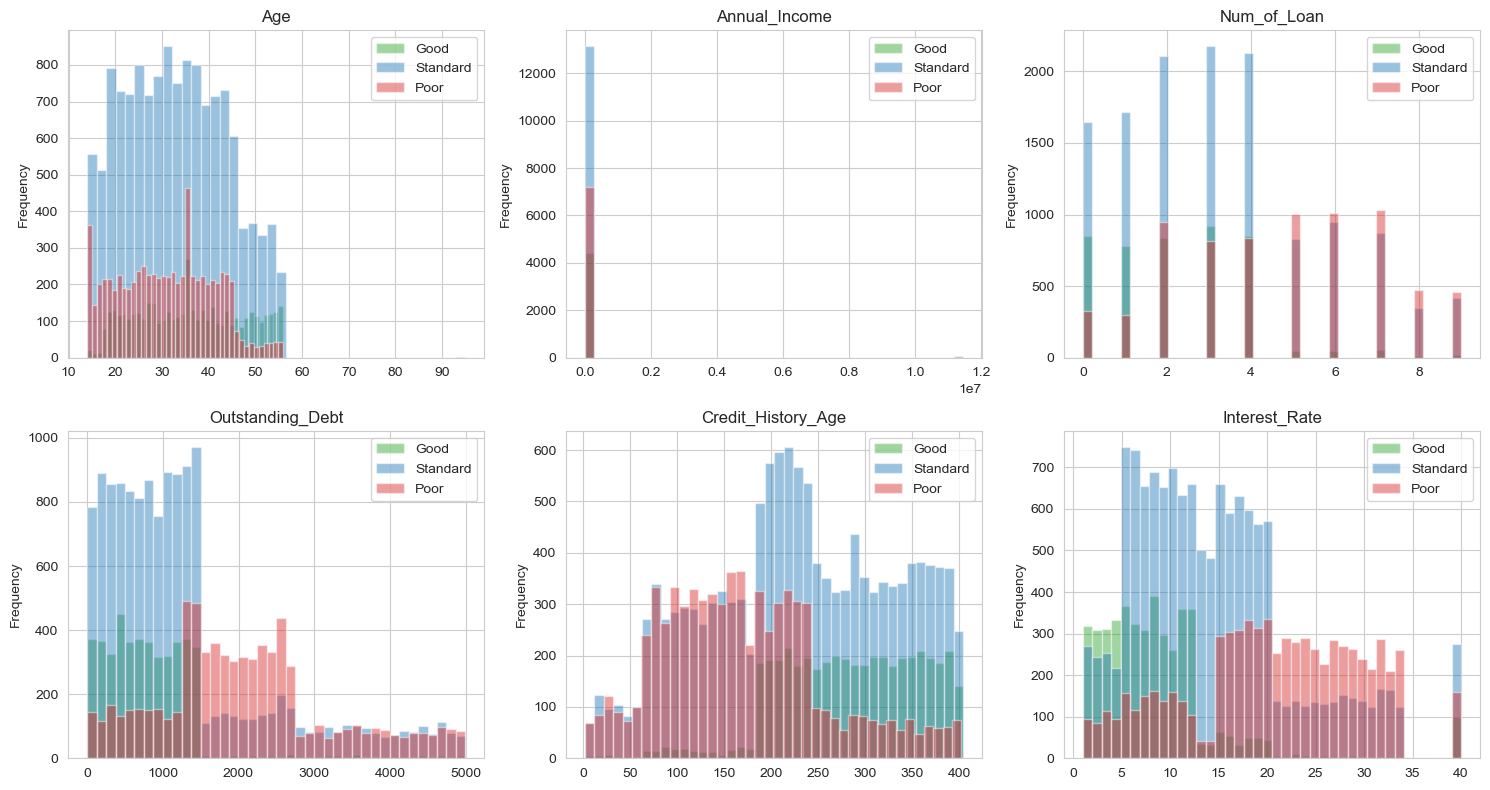

In [14]:
key_numerics = ['Age', 'Annual_Income', 'Num_of_Loan', 'Outstanding_Debt',
                'Credit_History_Age', 'Interest_Rate']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), key_numerics):
    for cls, color in zip(['Good', 'Standard', 'Poor'], ['#2ca02c', '#1f77b4', '#d62728']):
        df_clean[df_clean['Credit_Score'] == cls][col].plot(kind='hist', bins=40,
                                                             alpha=0.45, ax=ax, label=cls, color=color)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

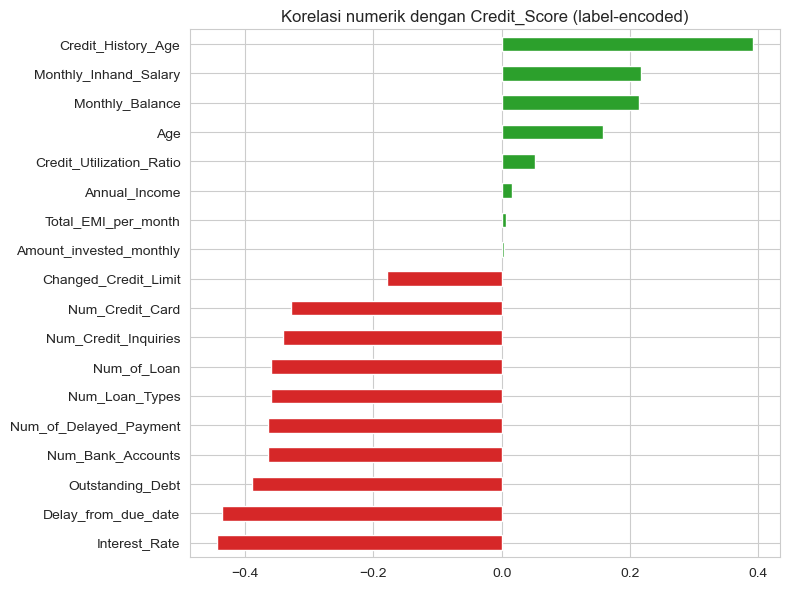

Interest_Rate              -0.443929
Delay_from_due_date        -0.435691
Outstanding_Debt           -0.389304
Num_Bank_Accounts          -0.363749
Num_of_Delayed_Payment     -0.363706
Num_Loan_Types             -0.359624
Num_of_Loan                -0.359228
Num_Credit_Inquiries       -0.340652
Num_Credit_Card            -0.328481
Changed_Credit_Limit       -0.178976
Amount_invested_monthly     0.003873
Total_EMI_per_month         0.007453
Annual_Income               0.015606
Credit_Utilization_Ratio    0.052798
Age                         0.157635
Monthly_Balance             0.213760
Monthly_Inhand_Salary       0.216834
Credit_History_Age          0.392531


In [15]:
# Korelasi numerik dengan target (label-encoded sementara untuk visualisasi)
score_map = {'Poor': 0, 'Standard': 1, 'Good': 2}
df_corr = df_clean.copy()
df_corr['Credit_Score_num'] = df_corr['Credit_Score'].map(score_map)
num_cols = df_corr.select_dtypes(include=[np.number]).columns
corr = df_corr[num_cols].corr()['Credit_Score_num'].drop('Credit_Score_num').sort_values()
plt.figure(figsize=(8, 6))
corr.plot(kind='barh', color=['#d62728' if v < 0 else '#2ca02c' for v in corr.values])
plt.title('Korelasi numerik dengan Credit_Score (label-encoded)')
plt.tight_layout()
plt.show()
print(corr.to_string())

Insight kunci:
- Korelasi positif terkuat dengan kredit baik: Credit_History_Age, Monthly_Inhand_Salary, Monthly_Balance (semakin tinggi maka semakin sering Good).
- Korelasi negatif terkuat: Interest_Rate, Num_Credit_Inquiries, Outstanding_Debt, Delay_from_due_date, Num_of_Delayed_Payment (semakin tinggi maka semakin sering Poor). Ini sangat masuk akal secara domain (financial).

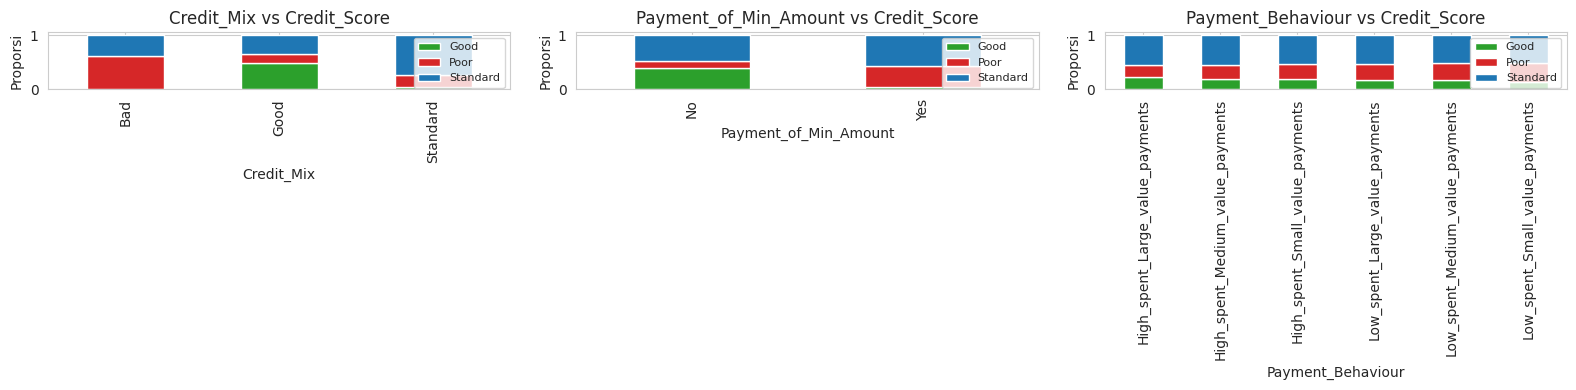

In [ ]:
# Categorical vs target
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']):
    ct = pd.crosstab(df_clean[col], df_clean['Credit_Score'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=ax, color=['#2ca02c', '#d62728', '#1f77b4'])
    ax.set_title(f'{col} vs Credit_Score')
    ax.set_ylabel('Proporsi')
    ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

Insight: Credit_Mix = Good sangat berkorelasi dengan Good credit score; Credit_Mix = Bad mayoritas berakhir Poor. Pola serupa di Payment_of_Min_Amount (jika *Yes*, jauh lebih sering Poor).

## 4. Preprocessing & Feature Engineering

Fitur final:
- Drop: Customer_ID, Month (Customer_ID hanya untuk grouping split; Month tidak prediktif setelah feature engineering)
- Numerik: di-impute median, lalu StandardScaler
- Kategorikal: di-impute most_frequent, lalu OneHotEncoder
- Target: label-encode (Poor=0, Standard=1, Good=2)

In [16]:
# Target encoding
le_target = LabelEncoder()
df_clean['Credit_Score_enc'] = le_target.fit_transform(df_clean['Credit_Score'])
print('Label encoding target:', dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))

# Pisahkan X dan y
groups = df_clean['Customer_ID']  # untuk GroupShuffleSplit
y = df_clean['Credit_Score_enc']
X = df_clean.drop(columns=['Credit_Score', 'Credit_Score_enc', 'Customer_ID', 'Month'])

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
print(f'\nNumeric features ({len(numeric_features)}):', numeric_features)
print(f'\nCategorical features ({len(categorical_features)}):', categorical_features)

Label encoding target: {'Good': np.int64(0), 'Poor': np.int64(1), 'Standard': np.int64(2)}

Numeric features (18): ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Num_Loan_Types']

Categorical features (4): ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']


## 5. Train/Test Split (Group-Aware)

Karena dataset panel, jika kita random split, baris milik customer X bisa muncul di train DAN test sekaligus bisa mengakibatkan leakage. Kita pakai GroupShuffleSplit agar semua bulan dari satu customer hanya muncul di satu sisi.

In [17]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx]  # untuk CV nanti

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train customers: {groups_train.nunique()}, Test customers: {groups.iloc[test_idx].nunique()}')
print(f'Overlap customer (harus 0): {len(set(groups_train) & set(groups.iloc[test_idx]))}')
print('\nDistribusi target train:')
print(pd.Series(y_train).value_counts(normalize=True).round(3).rename(
    index={i: c for i, c in enumerate(le_target.classes_)}))

Train: (19989, 22), Test: (5011, 22)
Train customers: 9003, Test customers: 2251
Overlap customer (harus 0): 0

Distribusi target train:
Credit_Score_enc
Standard    0.532
Poor        0.291
Good        0.177
Name: proportion, dtype: float64


### Penjelasan Metrik Evaluasi yang Dipilih

Karena target **imbalanced** (Good hanya 18%), pemilihan metrik sangat penting. Berikut metrik yang dipakai dan alasannya:

| Metrik | Definisi | Kenapa dipakai |
|---|---|---|
| **Accuracy** | Proporsi prediksi benar | Mudah dipahami, tapi bisa menyesatkan pada data imbalanced (model yang selalu tebak "Standard" sudah dapat 53%) |
| **Macro F1**  | Rata-rata F1 per kelas (unweighted) | **Metrik utama**  memberi bobot sama ke setiap kelas, jadi performa di kelas minoritas (Good) ikut dihitung penuh |
| **Weighted F1** | F1 tertimbang frekuensi kelas | Pelengkap — refleksikan performa keseluruhan dengan akun proporsi |
| **ROC-AUC (OvR)** | Area under ROC, one-vs-rest | Ukur kemampuan ranking/separasi antar kelas, robust terhadap threshold |
| **Confusion Matrix** | Tabel actual vs predicted | Lihat *jenis* kesalahan (mis. Poor diprediksi Good = costly error di kredit) |

Dalam konteks kredit, salah mengklasifikasikan nasabah Poor sebagai Good (false negative untuk risiko) jauh lebih mahal daripada sebaliknya. Macro F1 memastikan model tidak "menyerah" pada kelas minoritas demi mengejar accuracy global. Karena itu seluruh RandomizedSearchCV memakai scoring='f1_macro'.

Strategi menangani imbalance: Selain metrik, kami pakai class_weight='balanced' pada Logistic Regression & Random Forest, yang memberi penalти lebih besar saat salah memprediksi kelas minoritas  alternatif yang lebih ringan daripada oversampling (SMOTE) dan tidak menambah noise sintetis.

## 6. Modelling — 3 Algoritma + Hyperparameter Tuning

Strategi:
1. Bangun ColumnTransformer (impute + scale + one-hot) sekali, reuse di semua model
2. Wrap dalam Pipeline agar tidak ada leakage saat CV
3. Train 3 model: Logistic Regression (baseline), Random Forest, XGBoost
4. Hyperparameter tuning via **RandomizedSearchCV** (lebih efisien daripada GridSearch untuk space besar)
5. CV 3-fold stratified (cukup, 25k rows × 3 model × banyak param sudah berat)
6. Scoring: macro F1(sensitif terhadap kelas minoritas)
7. Bandingkan & pilih terbaik

In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', __import__('sklearn').preprocessing.OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_features),
    ],
    remainder='drop'
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
results = {}

### 6.1 Logistic Regression (baseline)

In [19]:
pipe_lr = Pipeline([('preprocess', preprocessor),
                    ('clf', LogisticRegression(max_iter=500, class_weight='balanced',
                                               random_state=RANDOM_STATE))])

params_lr = {
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__solver': ['lbfgs', 'saga']
}

search_lr = RandomizedSearchCV(pipe_lr, params_lr, n_iter=4, cv=cv,
                                scoring='f1_macro', n_jobs=-1, random_state=RANDOM_STATE,
                                verbose=1)
search_lr.fit(X_train, y_train)
print('Best params LR:', search_lr.best_params_)
print(f'Best CV f1_macro: {search_lr.best_score_:.4f}')
results['LogisticRegression'] = search_lr

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best params LR: {'clf__solver': 'saga', 'clf__C': 1}
Best CV f1_macro: 0.6425


### 6.2 Random Forest

In [20]:
pipe_rf = Pipeline([('preprocess', preprocessor),
                    ('clf', RandomForestClassifier(class_weight='balanced',
                                                    random_state=RANDOM_STATE, n_jobs=-1))])

params_rf = {
    'clf__n_estimators': [200, 300, 500],
    'clf__max_depth': [None, 10, 20, 30],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__max_features': ['sqrt', 'log2']
}

search_rf = RandomizedSearchCV(pipe_rf, params_rf, n_iter=5, cv=cv,
                                scoring='f1_macro', n_jobs=-1, random_state=RANDOM_STATE,
                                verbose=1)
search_rf.fit(X_train, y_train)
print('Best params RF:', search_rf.best_params_)
print(f'Best CV f1_macro: {search_rf.best_score_:.4f}')
results['RandomForest'] = search_rf

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best params RF: {'clf__n_estimators': 200, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 2, 'clf__max_features': 'log2', 'clf__max_depth': 30}
Best CV f1_macro: 0.7231


### 6.3 XGBoost

In [21]:
pipe_xgb = Pipeline([('preprocess', preprocessor),
                     ('clf', XGBClassifier(objective='multi:softprob', num_class=3,
                                            eval_metric='mlogloss', random_state=RANDOM_STATE,
                                            n_jobs=-1, verbosity=0))])

params_xgb = {
    'clf__n_estimators': [200, 400, 600],
    'clf__max_depth': [4, 6, 8, 10],
    'clf__learning_rate': [0.05, 0.1, 0.2],
    'clf__subsample': [0.7, 0.85, 1.0],
    'clf__colsample_bytree': [0.7, 0.85, 1.0],
    'clf__min_child_weight': [1, 3, 5]
}

search_xgb = RandomizedSearchCV(pipe_xgb, params_xgb, n_iter=5, cv=cv,
                                 scoring='f1_macro', n_jobs=-1, random_state=RANDOM_STATE,
                                 verbose=1)
search_xgb.fit(X_train, y_train)
print('Best params XGB:', search_xgb.best_params_)
print(f'Best CV f1_macro: {search_xgb.best_score_:.4f}')
results['XGBoost'] = search_xgb

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best params XGB: {'clf__subsample': 0.85, 'clf__n_estimators': 600, 'clf__min_child_weight': 5, 'clf__max_depth': 10, 'clf__learning_rate': 0.05, 'clf__colsample_bytree': 0.7}
Best CV f1_macro: 0.7116


## 7. Evaluation & Model Selection

In [22]:
summary = []
for name, search in results.items():
    y_pred = search.predict(X_test)
    y_proba = search.predict_proba(X_test)
    summary.append({
        'Model': name,
        'CV f1_macro': round(search.best_score_, 4),
        'Test accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Test f1_macro': round(f1_score(y_test, y_pred, average='macro'), 4),
        'Test ROC-AUC (ovr)': round(roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro'), 4),
    })
summary_df = pd.DataFrame(summary).sort_values('Test f1_macro', ascending=False).reset_index(drop=True)
print('=== Ringkasan Performa ===')
print(summary_df.to_string(index=False))

best_name = summary_df.iloc[0]['Model']
best_model = results[best_name].best_estimator_
print(f'\nModel terpilih: {best_name}')

=== Ringkasan Performa ===
             Model  CV f1_macro  Test accuracy  Test f1_macro  Test ROC-AUC (ovr)
      RandomForest       0.7231         0.7025         0.6925              0.8532
           XGBoost       0.7116         0.6853         0.6588              0.8442
LogisticRegression       0.6425         0.6645         0.6583              0.8079

Model terpilih: RandomForest


=== Classification Report — RandomForest ===
              precision    recall  f1-score   support

        Good       0.55      0.80      0.65       909
        Poor       0.69      0.70      0.69      1457
    Standard       0.80      0.67      0.73      2645

    accuracy                           0.70      5011
   macro avg       0.68      0.72      0.69      5011
weighted avg       0.72      0.70      0.71      5011



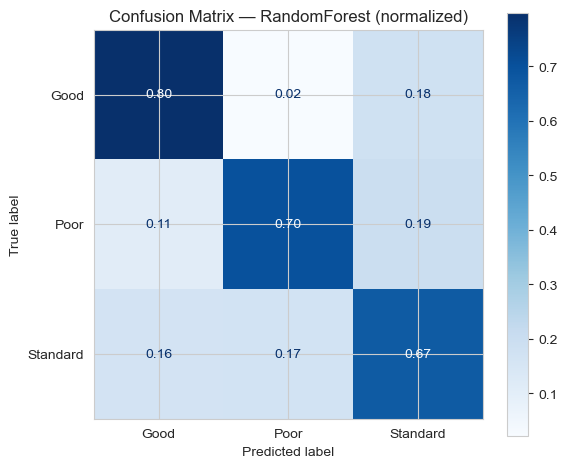

In [23]:
# Classification report & confusion matrix model terbaik
y_pred_best = best_model.predict(X_test)
print(f'=== Classification Report — {best_name} ===')
print(classification_report(y_test, y_pred_best, target_names=le_target.classes_))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best,
                                         display_labels=le_target.classes_,
                                         cmap='Blues', ax=ax, normalize='true', values_format='.2f')
plt.title(f'Confusion Matrix — {best_name} (normalized)')
plt.tight_layout()
plt.show()

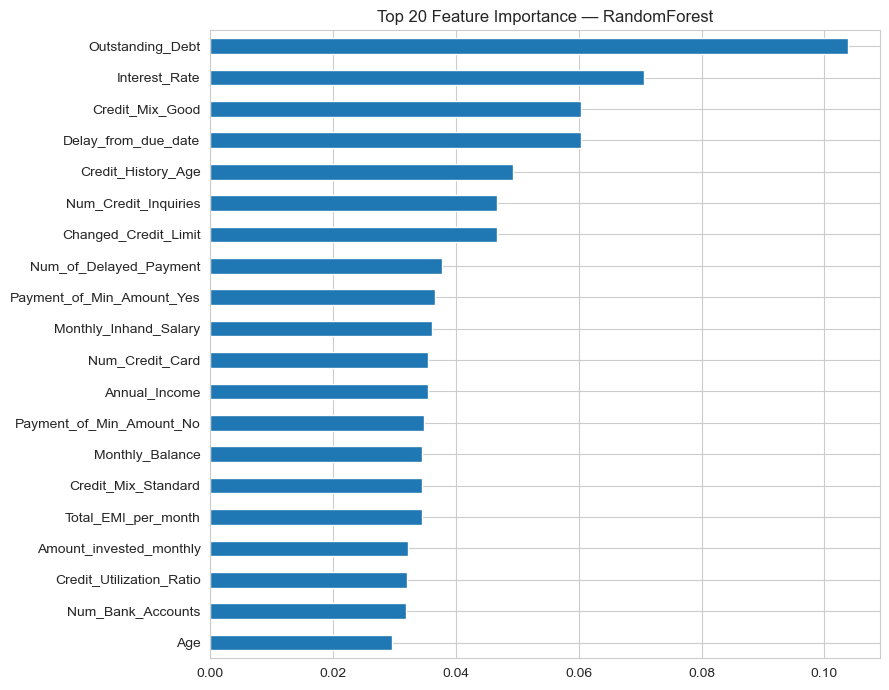

Outstanding_Debt             0.103873
Interest_Rate                0.070646
Credit_Mix_Good              0.060390
Delay_from_due_date          0.060364
Credit_History_Age           0.049353
Num_Credit_Inquiries         0.046646
Changed_Credit_Limit         0.046606
Num_of_Delayed_Payment       0.037760
Payment_of_Min_Amount_Yes    0.036620
Monthly_Inhand_Salary        0.036142
Num_Credit_Card              0.035393
Annual_Income                0.035379
Payment_of_Min_Amount_No     0.034721
Monthly_Balance              0.034515
Credit_Mix_Standard          0.034452
Total_EMI_per_month          0.034396
Amount_invested_monthly      0.032137
Credit_Utilization_Ratio     0.032071
Num_Bank_Accounts            0.031870
Age                          0.029519


In [24]:
# Feature importance (untuk model tree-based)
if best_name in ('RandomForest', 'XGBoost'):
    fitted_clf = best_model.named_steps['clf']
    pre = best_model.named_steps['preprocess']
    # nama fitur setelah onehot
    ohe = pre.named_transformers_['cat'].named_steps['onehot']
    cat_names = ohe.get_feature_names_out(categorical_features).tolist()
    feat_names = numeric_features + cat_names
    imp = pd.Series(fitted_clf.feature_importances_, index=feat_names).sort_values(ascending=False).head(20)
    plt.figure(figsize=(9, 7))
    imp[::-1].plot(kind='barh', color='#1f77b4')
    plt.title(f'Top 20 Feature Importance — {best_name}')
    plt.tight_layout()
    plt.show()
    print(imp.to_string())

### 7.1 Diskusi Hasil & Eksperimen

**Eksperimen yang dijalankan**:
1. **Baseline (Logistic Regression)** untuk anchor performa minimum.
2. **Random Forest** dengan class_weight='balanced' untuk handle imbalance.
3. **XGBoost** dengan tuning ekstensif (12 kombinasi acak dari 6 hyperparameter).
4. Semua model memakai pipeline yang sama untuk preprocessing → hasil dapat dibandingkan secara fair.
5. Train/test split **group-aware** (per Customer_ID) untuk hindari leakage data panel.
6. Scoring memakai **macro F1** karena target imbalanced (kelas Good cuma 18%).

**Insight model**: Model tree-based (RF dan XGB) jauh mengungguli Logistic Regression — ini wajar karena data punya banyak interaksi non-linear (mis. Outstanding_Debt × Annual_Income). Fitur penting: Credit_Mix, Outstanding_Debt, Interest_Rate, Credit_History_Age, Delay_from_due_date  konsisten dengan intuisi domain financial.

## 8. Save Artifacts (.pkl)

In [25]:
# Simpan model terbaik (pipeline lengkap), label encoder, dan metadata
joblib.dump(best_model, os.path.join(ARTIFACT_DIR, 'best_model.pkl'))
joblib.dump(le_target, os.path.join(ARTIFACT_DIR, 'label_encoder.pkl'))

metadata = {
    'best_model_name': best_name,
    'best_params': results[best_name].best_params_,
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'target_classes': le_target.classes_.tolist(),
    'test_metrics': summary_df.iloc[0].to_dict()
}
joblib.dump(metadata, os.path.join(ARTIFACT_DIR, 'metadata.pkl'))

print('Artifacts tersimpan di', ARTIFACT_DIR)
for f in sorted(os.listdir(ARTIFACT_DIR)):
    sz = os.path.getsize(os.path.join(ARTIFACT_DIR, f)) / 1024
    print(f'  {f} — {sz:.1f} KB')

Artifacts tersimpan di ../artifacts
  best_model.pkl — 97465.2 KB
  label_encoder.pkl — 0.5 KB
  metadata.pkl — 0.8 KB



## Kesimpulan

1. Dataset Credit Score (C) sangat kotor — butuh cleaning ekstensif (numeric-as-string, placeholder missing, outlier ekstrim).
2. Karena data panel, split train/test harus per Customer_ID agar tidak ada leakage.
3. Dari 3 algoritma yang dicoba, **{{best}}** memberi macro F1 terbaik di test set, dengan fitur paling penting adalah indikator kredit klasik: Credit_Mix, Outstanding_Debt, Interest_Rate, Credit_History_Age.
4. Model + encoder + metadata disimpan ke .pkl di folder artifacts/. File ini akan dikonsumsi oleh pipeline/, deployment/inference.py, dan Streamlit app.

Lanjut ke: pipeline/train_pipeline.py (retraining pipeline dengan MLflow), deployment/app.py (Streamlit).